In [1]:
# Rental Prices in Bahrain
# predicting monthly rent (BHD) for residential listings using property_finder.bh data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import f_regression, SelectFpr
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [2]:
df = pd.read_csv('data/data.csv')
test = pd.read_csv('data/test.csv')
sub_template = pd.read_csv('data/sample_submission.csv')

df.shape, test.shape

((10578, 16), (3527, 15))

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10578 entries, 0 to 10577
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Property_id        10578 non-null  int64  
 1   Offer              10578 non-null  str    
 2   URL                10578 non-null  str    
 3   Property_type      10578 non-null  str    
 4   Include_w_e        10578 non-null  str    
 5   Title              10575 non-null  str    
 6   Area               10575 non-null  str    
 7   Governorate        10575 non-null  str    
 8   Beds               10578 non-null  str    
 9   Baths              10578 non-null  str    
 10  Size               10578 non-null  str    
 11  Availability_date  10059 non-null  str    
 12  Agent_name         10575 non-null  str    
 13  Agency             10575 non-null  str    
 14  Amenities          10272 non-null  float64
 15  rent               10575 non-null  float64
dtypes: float64(2), int64(1), str(13)


In [4]:
df.isnull().sum()

Property_id            0
Offer                  0
URL                    0
Property_type          0
Include_w_e            0
Title                  3
Area                   3
Governorate            3
Beds                   0
Baths                  0
Size                   0
Availability_date    519
Agent_name             3
Agency                 3
Amenities            306
rent                   3
dtype: int64

In [5]:
# the 3 rows missing rent are also missing Title/Area/Governorate/Agent/Agency, whole rows are broken
df[df['rent'].isnull()]

,Property_id,Offer,URL,Property_type,Include_w_e,Title,Area,Governorate,Beds,Baths,Size,Availability_date,Agent_name,Agency,Amenities,rent
5194,125,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,NaN,NaN,NaN,2,4,"1,399 sqft / 130 sqm",NaN,NaN,NaN,5.0,NaN
6787,25,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,NaN,NaN,NaN,2,4,"1,399 sqft / 130 sqm",NaN,NaN,NaN,5.0,NaN
7864,9012,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Inclusive,NaN,NaN,NaN,2,2,"1,184 sqft / 110 sqm",NaN,NaN,NaN,8.0,NaN


In [6]:
df = df.dropna(subset=['rent'])
df['rent'].describe()

count     10575.000000
mean        718.750071
std        5318.027519
min          50.000000
25%         330.000000
50%         450.000000
75%         700.000000
max      400000.000000
Name: rent, dtype: float64

In [7]:
# std is way bigger than the mean, checked the top end
df.nlargest(10, 'rent')[['Title', 'Property_type', 'Area', 'Size', 'rent']]

,Title,Property_type,Area,Size,rent
7195,Spacious Villa | Patel 5 | 4 Bedrooms,Villa,Durrat Al Bahrain,"5,866 sqft / 545 sqm",400000.0
9399,UNDER CONSTRUCTION VILLA IN MUHARRAQ,Villa,Muharraq,"4,036 sqft / 375 sqm",230000.0
2131,New Villa in karzakan Size 331 SQM,Villa,Karzakkan,"4,844 sqft / 450 sqm",146500.0
7248,Amazing House for Sale in Hidd,Villa,Hidd,"5,813 sqft / 540 sqm",145000.0
4397,Villa for sale in Sadad,Villa,Sadad,"2,939 sqft / 273 sqm",130000.0
9018,| CITY CENTER | MODERN | CITY VIEW | HIGH FLOOR |,Apartment,Seef,"1,432 sqft / 133 sqm",86000.0
292,Exclusive Offer | Resort-Style Living | Spacious,Apartment,"Breeze of Dilmunia, Dilmunia Island","1,012 sqft / 94 sqm",72000.0
7277,High Floor | Mall View | Beach Access,Apartment,"Marassi Shores Residences, Diyar Al Muharraq",710 sqft / 66 sqm,69000.0
3810,Modern | For Rent &amp; Sale | Sea View + Balcony,Villa,"Durrat Marina, Durrat Al Bahrain","1,292 sqft / 120 sqm",55000.0
4602,BRAND NEW BUILDING | PRIME LOCATION | 3BHK,Apartment,Hamad Town,"1,561 sqft / 145 sqm",55000.0


In [8]:
# titles say "for sale", these are sale prices entered under rent by mistake, not real monthly rent
# there's a clean gap between 6500 and 8400, so rows above 8000 got cut
df = df[df['rent'] <= 8000]
df['rent'].describe()

count    10556.000000
mean       573.141531
std        399.357544
min         50.000000
25%        330.000000
50%        450.000000
75%        700.000000
max       6500.000000
Name: rent, dtype: float64

In [9]:
# same listing can be scraped more than once, dropped exact duplicates (ignoring the id column)
df.drop(columns='Property_id').duplicated().sum()

np.int64(239)

In [10]:
df = df.drop_duplicates(subset=df.columns.drop('Property_id'))
df.shape

(10317, 16)

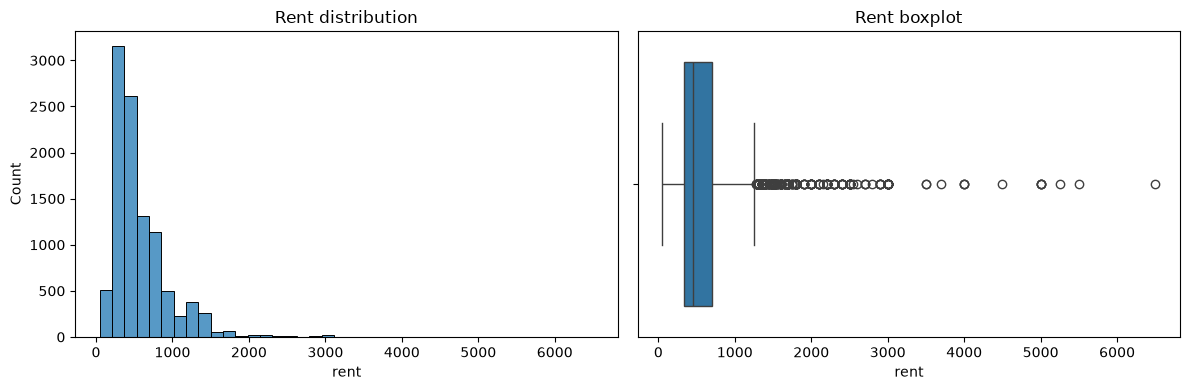

In [11]:
# EDA
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['rent'], bins=40, ax=axes[0])
axes[0].set_title('Rent distribution')
sns.boxplot(x=df['rent'], ax=axes[1])
axes[1].set_title('Rent boxplot')
plt.tight_layout()
plt.show()
# still right-skewed even after cutting the sale-price rows, most units rent under 1000 BHD

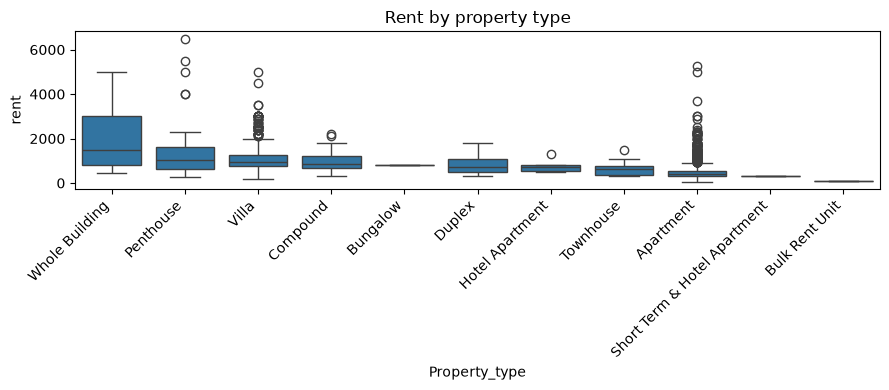

In [12]:
order = df.groupby('Property_type')['rent'].median().sort_values(ascending=False).index
plt.figure(figsize=(9, 4))
sns.boxplot(data=df, x='Property_type', y='rent', order=order)
plt.xticks(rotation=45, ha='right')
plt.title('Rent by property type')
plt.tight_layout()
plt.show()

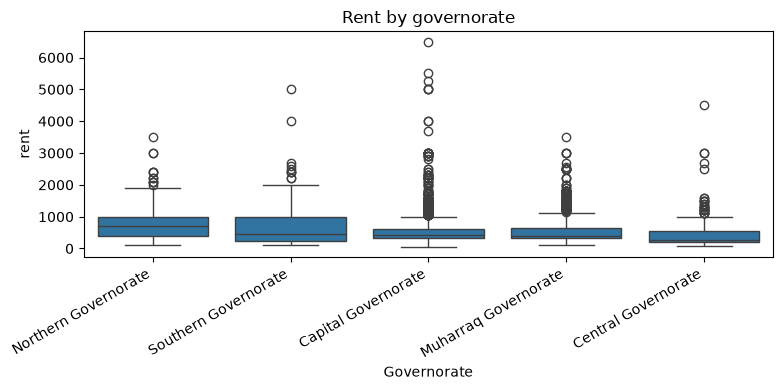

In [13]:
order = df.groupby('Governorate')['rent'].median().sort_values(ascending=False).index
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Governorate', y='rent', order=order)
plt.xticks(rotation=30, ha='right')
plt.title('Rent by governorate')
plt.tight_layout()
plt.show()
# Northern has the highest median rent, Central the lowest

In [14]:
# Cleaning
df['Beds'].unique(), df['Baths'].unique()

(<ArrowStringArray>
 [     '3+ Maid',            '5',       'studio',            '3',
       '5+ Maid',            '2',      '4+ Maid',            '1',
       '2+ Maid',            '4',            '6',      '1+ Maid',
       '6+ Maid', 'studio+ Maid',            '0',            '7',
            '7+',      '7+ Maid',     '7++ Maid']
 Length: 19, dtype: str,
 <ArrowStringArray>
 ['4', '6', '1', '3', '5', '2', '7+', '7', 'none']
 Length: 9, dtype: str)

In [15]:
# Beds mixes a number with "+ Maid"/"studio", parsed into Beds_num plus a separate has_maid flag; Baths just needed "none"->0 and "7+"->7
def parse_beds(v):
    if 'studio' in v:
        return 0
    return int(v.replace('+ Maid', '').replace('+', ''))

df['Beds_num'] = df['Beds'].apply(parse_beds)
df['has_maid'] = df['Beds'].str.contains('Maid').astype(int)
df['Baths_num'] = df['Baths'].apply(lambda v: 0 if v == 'none' else int(v.replace('+', '')))

df[['Beds', 'Beds_num', 'has_maid', 'Baths', 'Baths_num']].sample(5)

,Beds,Beds_num,has_maid,Baths,Baths_num
10334,6+ Maid,6,1,7,7
7006,4+ Maid,4,1,5,5
7725,1,1,0,1,1
822,1,1,0,2,2
10159,2,2,0,1,1


In [16]:
# Size is "X sqft / Y sqm", kept sqft as a single numeric column
df['Size_sqft'] = df['Size'].str.extract(r'([\d,]+) sqft')[0].str.replace(',', '').astype(float)
df['Size_sqft'].describe()

count    10317.000000
mean      1817.173306
std       1627.043698
min         11.000000
25%        969.000000
50%       1345.000000
75%       1938.000000
max      53820.000000
Name: Size_sqft, dtype: float64

In [17]:
# dropped URL/Title/Agent_name/Agency/Offer (too specific or constant) and the raw Beds/Baths/Size text now that numeric versions exist
cat_cols = ['Property_type', 'Include_w_e', 'Governorate', 'Area']
num_cols = ['Beds_num', 'has_maid', 'Baths_num', 'Size_sqft', 'Amenities']

df_clean = df.dropna(subset=cat_cols + ['Size_sqft']).copy()
df_clean = df_clean[cat_cols + num_cols + ['rent']]
df_clean.info()

<class 'pandas.DataFrame'>
Index: 10317 entries, 0 to 10577
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Property_type  10317 non-null  str    
 1   Include_w_e    10317 non-null  str    
 2   Governorate    10317 non-null  str    
 3   Area           10317 non-null  str    
 4   Beds_num       10317 non-null  int64  
 5   has_maid       10317 non-null  int64  
 6   Baths_num      10317 non-null  int64  
 7   Size_sqft      10317 non-null  float64
 8   Amenities      10017 non-null  float64
 9   rent           10317 non-null  float64
dtypes: float64(3), int64(3), str(4)
memory usage: 1.4 MB


In [18]:
# validated: no leftover text columns, no negative/zero sizes, Amenities is the only column still allowed nulls (imputed in the pipeline)
print(df_clean[num_cols].describe())
print(df_clean.isnull().sum())

           Beds_num      has_maid     Baths_num     Size_sqft     Amenities
count  10317.000000  10317.000000  10317.000000  10317.000000  10017.000000
mean       2.198701      0.210139      2.659203   1817.173306     10.306679
std        1.200792      0.407427      1.286573   1627.043698      5.092063
min        0.000000      0.000000      0.000000     11.000000      1.000000
25%        1.000000      0.000000      2.000000    969.000000      6.000000
50%        2.000000      0.000000      2.000000   1345.000000     11.000000
75%        3.000000      0.000000      3.000000   1938.000000     14.000000
max        7.000000      1.000000      7.000000  53820.000000     25.000000
Property_type      0
Include_w_e        0
Governorate        0
Area               0
Beds_num           0
has_maid           0
Baths_num          0
Size_sqft          0
Amenities        300
rent               0
dtype: int64


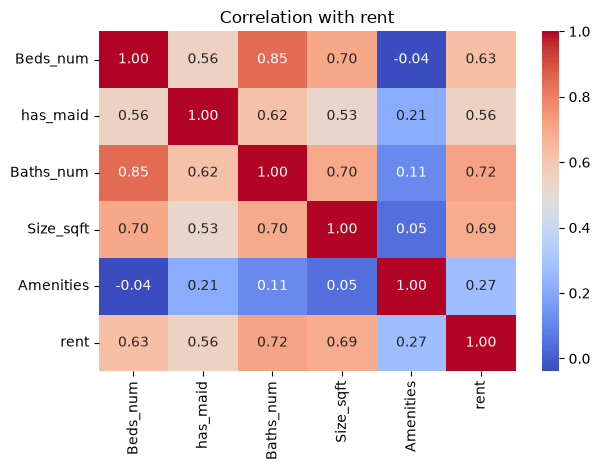

In [19]:
sns.heatmap(df_clean[num_cols + ['rent']].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation with rent')
plt.tight_layout()
plt.show()
# Baths_num and Size_sqft correlate with rent the strongest, Amenities barely moves it

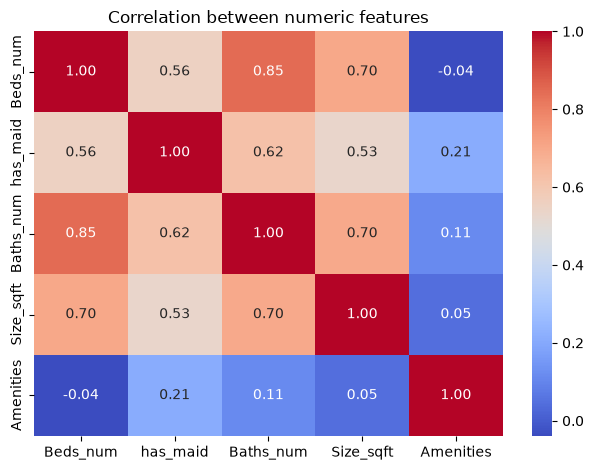

In [20]:
# checked the numeric features against each other: Beds_num/Baths_num correlate highly (0.85), Size_sqft ~0.70 with both, Amenities is independent
sns.heatmap(df_clean[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation between numeric features')
plt.tight_layout()
plt.show()

In [21]:
# Skew fixes before modeling
df_clean[num_cols + ['rent']].skew()

Beds_num     0.594483
has_maid     1.423165
Baths_num    0.983041
Size_sqft    7.430063
Amenities   -0.021398
rent         3.244211
dtype: float64

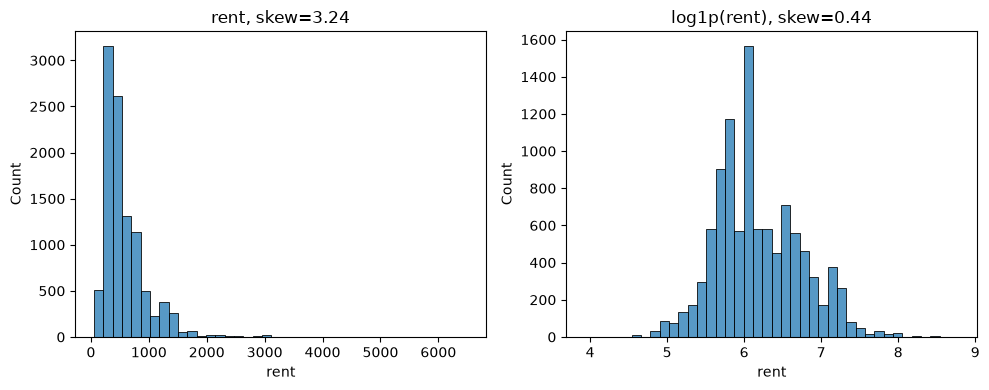

In [22]:
# rent is by far the most skewed (3.24), log1p brings it close to symmetric
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df_clean['rent'], bins=40, ax=axes[0])
axes[0].set_title(f"rent, skew={df_clean['rent'].skew():.2f}")
sns.histplot(np.log1p(df_clean['rent']), bins=40, ax=axes[1])
axes[1].set_title(f"log1p(rent), skew={np.log1p(df_clean['rent']).skew():.2f}")
plt.tight_layout()
plt.show()

In [23]:
# Size_sqft (skew 7.43) got a power-transform tested via cross_val_score, it made Ridge's CV MAE worse (133 -> 146) so it was left alone; Beds_num/Baths_num are small ordinal counts, not worth transforming

In [24]:
# Pipeline and modeling
X = df_clean[cat_cols + num_cols]
y = df_clean['rent']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((8253, 9), (2064, 9))

In [25]:
# ANOVA and PCA
# order is correlation -> ANOVA -> PCA, since PCA collapses features into unnamed components ANOVA couldn't use if it ran first; both fit on X_train only
pre = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', SimpleImputer(strategy='median'), num_cols)
])
X_train_encoded = pre.fit_transform(X_train, y_train)
feature_names = pre.get_feature_names_out()

F, p_values = f_regression(X_train_encoded, y_train)
anova_results = pd.DataFrame({'feature': feature_names, 'F': F, 'p_value': p_values}).sort_values('p_value')

print('significant at p<0.05:', (anova_results['p_value'] < 0.05).sum(), '/', len(anova_results))
anova_results[anova_results['feature'].str.startswith('num__')]

significant at p<0.05: 75 / 146


,feature,F,p_value
141,num__Beds_num,5514.480802,0.000000e+00
143,num__Baths_num,8926.363251,0.000000e+00
144,num__Size_sqft,7783.058170,0.000000e+00
142,num__has_maid,3802.530463,0.000000e+00
145,num__Amenities,623.326571,1.083915e-132


In [26]:
# all 5 numeric features are significant, the insignificant ones are almost all rare Area categories
anova_results[anova_results['p_value'] >= 0.05].tail(10)

,feature,F,p_value
108,cat__Area_Northern City (Madinat Salman),0.074891,0.784351
35,cat__Area_Al Qurayyah,0.070831,0.790137
44,"cat__Area_Amwaj Marina, Amwaj Islands",0.062968,0.801871
41,"cat__Area_Amwaj Beachfront, Amwaj Islands",0.058956,0.808160
133,"cat__Area_The Treasure, Dilmunia Island",0.052001,0.819623
98,"cat__Area_Marassi Park Residences, Diyar Al Mu...",0.037563,0.846329
36,"cat__Area_Al Sherooq, Diyar Al Muharraq",0.037432,0.846594
58,cat__Area_Buri,0.033110,0.855617
20,"cat__Area_Address Marassi Vista, Diyar Al Muha...",0.002317,0.961609
40,"cat__Area_Amwaj Avenue, Amwaj Islands",0.000687,0.979087


In [27]:
# PCA on the numeric block, since that's where the correlation showed up (Beds_num/Baths_num/Size_sqft); scaled first since PCA is variance-based, fit only on X_train
num_pca_pipe = Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler()), ('pca', PCA(random_state=42))])
num_pca_pipe.fit(X_train[num_cols])
np.cumsum(num_pca_pipe.named_steps['pca'].explained_variance_ratio_)

array([0.60380016, 0.81307336, 0.9045331 , 0.97291148, 1.        ])

In [28]:
# 4 components hold 97% of the numeric variance, tested whether keeping only the "important" data (PCA or ANOVA-significant features) actually helps instead of assuming it does
def make_rf(pca=False, anova_select=False):
    num_steps = [('impute', SimpleImputer(strategy='median'))]
    if pca:
        num_steps += [('scale', StandardScaler()), ('pca', PCA(n_components=0.95, random_state=42))]
    pre = ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', Pipeline(num_steps), num_cols)
    ])
    steps = [('pre', pre)]
    if anova_select:
        steps.append(('anova', SelectFpr(f_regression, alpha=0.05)))
    steps.append(('model', RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)))
    return TransformedTargetRegressor(regressor=Pipeline(steps), func=np.log1p, inverse_func=np.expm1)

for label, pca_flag, anova_flag in [('baseline, all features', False, False),
                                     ('PCA(0.95) on numeric block', True, False),
                                     ('ANOVA-selected features only (p<0.05)', False, True)]:
    scores = cross_val_score(make_rf(pca_flag, anova_flag), X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
    print(label, 'CV MAE:', -scores.mean())

baseline, all features CV MAE: 110.79388228475014


PCA(0.95) on numeric block CV MAE: 115.4671740216349


ANOVA-selected features only (p<0.05) CV MAE: 112.49762753184919


In [29]:
# both PCA and ANOVA-based trimming made CV MAE worse since RandomForest already handles irrelevant/redundant features on its own, so the full untransformed feature set was kept for the final model

In [30]:
# two preprocessors: linear models get scaled numerics, trees don't need scaling
scaled_pre = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), num_cols)
])
plain_pre = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', SimpleImputer(strategy='median'), num_cols)
])

# one pipeline + param grid per candidate model, LinearRegression has no hyperparameters worth tuning
model_configs = {
    'LinearRegression': (
        Pipeline([('pre', scaled_pre), ('model', LinearRegression())]),
        {}
    ),
    'Ridge': (
        Pipeline([('pre', scaled_pre), ('model', Ridge())]),
        {'model__alpha': [0.1, 1, 10, 100]}
    ),
    'DecisionTree': (
        Pipeline([('pre', plain_pre), ('model', DecisionTreeRegressor(random_state=42))]),
        {'model__max_depth': [5, 10, 15, None], 'model__min_samples_leaf': [1, 5, 10]}
    ),
    'RandomForest': (
        Pipeline([('pre', plain_pre), ('model', RandomForestRegressor(random_state=42, n_jobs=-1))]),
        {'model__n_estimators': [200, 300], 'model__max_depth': [None, 20], 'model__min_samples_leaf': [1, 2]}
    ),
}

In [31]:
# 5-fold grid search per model, all fit on X_train only; y is logged inside TransformedTargetRegressor
fitted_models = {}
results = []

for name, (pipe, grid) in model_configs.items():
    ttr = TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)
    grid = {f'regressor__{k}': v for k, v in grid.items()}

    if grid:
        search = GridSearchCV(ttr, grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
        search.fit(X_train, y_train)
        best_model, cv_mae, best_params = search.best_estimator_, -search.best_score_, search.best_params_
    else:
        ttr.fit(X_train, y_train)
        best_model = ttr
        cv_mae = -cross_val_score(ttr, X_train, y_train, cv=5, scoring='neg_mean_absolute_error').mean()
        best_params = {}

    test_mae = mean_absolute_error(y_test, best_model.predict(X_test))
    fitted_models[name] = best_model
    results.append({'model': name, 'cv_mae': cv_mae, 'test_mae': test_mae, 'best_params': best_params})

results_df = pd.DataFrame(results).sort_values('test_mae').reset_index(drop=True)
results_df

,model,cv_mae,test_mae,best_params
0,RandomForest,109.743228,109.930552,"{'regressor__model__max_depth': 20, 'regressor..."
1,LinearRegression,122.000256,121.376540,{}
2,Ridge,121.889128,121.469835,{'regressor__model__alpha': 1}
3,DecisionTree,126.413295,130.149981,"{'regressor__model__max_depth': 15, 'regressor..."


In [32]:
# Randomized search, 1000 iterations
# 1000 iterations x 5-fold CV at n_estimators=1000 would take 15+ hours, so the search used a cheap n_estimators=100 instead (ranking is stable at 100 trees) and refit the winner at n_estimators=1000
rf_pre = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', SimpleImputer(strategy='median'), num_cols)
])
search_reg = Pipeline([('pre', rf_pre), ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1))])
search_ttr = TransformedTargetRegressor(regressor=search_reg, func=np.log1p, inverse_func=np.expm1)

param_dist = {
    'regressor__model__max_depth': randint(5, 40),
    'regressor__model__min_samples_leaf': randint(1, 20),
    'regressor__model__min_samples_split': randint(2, 20),
    'regressor__model__max_features': [0.3, 0.5, 0.7, 1.0, 'sqrt'],
}

random_search = RandomizedSearchCV(search_ttr, param_dist, n_iter=1000, cv=3,
                                    scoring='neg_mean_absolute_error', random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

random_search.best_params_, -random_search.best_score_

({'regressor__model__max_depth': 39,
  'regressor__model__max_features': 'sqrt',
  'regressor__model__min_samples_leaf': 1,
  'regressor__model__min_samples_split': 4},
 np.float64(110.77030791367714))

In [33]:
# refit the winning hyperparameters with the full 1000 trees for the actual model
best_params = {k.replace('regressor__model__', ''): v for k, v in random_search.best_params_.items()}
tuned_reg = Pipeline([('pre', rf_pre), ('model', RandomForestRegressor(n_estimators=1000, random_state=42, n_jobs=-1, **best_params))])
tuned_rf = TransformedTargetRegressor(regressor=tuned_reg, func=np.log1p, inverse_func=np.expm1)
tuned_rf.fit(X_train, y_train)

mean_absolute_error(y_test, tuned_rf.predict(X_test))

109.27179896042311

In [34]:
# the 1000-iteration search (109.3 test MAE) edges out the earlier small grid search (109.9), go with the tuned one
final_pipe = tuned_rf
test_pred = final_pipe.predict(X_test)
mean_absolute_error(y_test, test_pred)

109.27179896042311

In [35]:
# Predict on test set
# same feature engineering as the training set, test.csv has no missing categoricals or sizes so no rows need dropping
test['Beds_num'] = test['Beds'].apply(parse_beds)
test['has_maid'] = test['Beds'].str.contains('Maid').astype(int)
test['Baths_num'] = test['Baths'].apply(lambda v: 0 if v == 'none' else int(v.replace('+', '')))
test['Size_sqft'] = test['Size'].str.extract(r'([\d,]+) sqft')[0].str.replace(',', '').astype(float)

test.isnull().sum()[num_cols]

Beds_num      0
has_maid      0
Baths_num     0
Size_sqft     0
Amenities    86
dtype: int64

In [36]:
# refit on all of df_clean (train + validation split) before predicting on the actual test set
final_pipe.fit(X, y)

X_submit = test[cat_cols + num_cols]
test_predictions = final_pipe.predict(X_submit)

submission = pd.DataFrame({'Property_id': test['Property_id'], 'rent': test_predictions})
submission.head()

,Property_id,rent
0,4394,430.139284
1,2338,630.345218
2,8531,768.761049
3,8952,392.949892
4,11064,299.494367


In [37]:
# matched the sample submission's column order and row order before saving
submission = submission[sub_template.columns]
submission = submission.set_index('Property_id').loc[sub_template['Property_id']].reset_index()
submission.to_csv('data/submission.csv', index=False)
submission.shape

(3527, 2)